<a href="https://www.kaggle.com/code/chandunarisetti/car-dataset-prediction?scriptVersionId=220935581" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/vehicle-dataset-from-cardekho/car data.csv
/kaggle/input/vehicle-dataset-from-cardekho/car details v4.csv
/kaggle/input/vehicle-dataset-from-cardekho/CAR DETAILS FROM CAR DEKHO.csv
/kaggle/input/vehicle-dataset-from-cardekho/Car details v3.csv


# importing the depedencies

In [2]:
import pandas as pd
pd.set_option('future.no_silent_downcasting', True)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn import metrics
from sklearn.ensemble import RandomForestRegressor

# Data collection and preprocessing

In [3]:
# loading the data from csv file to pandas dataframe
car_dataset=pd.read_csv("/kaggle/input/vehicle-dataset-from-cardekho/car data.csv")

In [4]:
# inspecting the first 5 rows of the dataframe
car_dataset.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [5]:
# checking the number of rows and columns
car_dataset.shape

(301, 9)

In [6]:
# getting some information about the dataset
car_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [7]:
# checking the number of missing values
car_dataset.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [8]:
#checking the distribution of the categorical data
print(car_dataset.Fuel_Type.value_counts())
print(car_dataset.Seller_Type.value_counts())
print(car_dataset.Transmission.value_counts())

Fuel_Type
Petrol    239
Diesel     60
CNG         2
Name: count, dtype: int64
Seller_Type
Dealer        195
Individual    106
Name: count, dtype: int64
Transmission
Manual       261
Automatic     40
Name: count, dtype: int64


# Encoding the Categorical Data

In [9]:
# encoding "Fuel_Type" Column
car_dataset.replace({"Fuel_Type":{"Petrol":0, "Diesel":1, "CNG":2}}, inplace=True)

# encoding "Seller_Type" Column
car_dataset.replace({"Seller_Type":{"Dealer":0, "Individual":1}}, inplace=True)

# encoding "Transmission" Column
car_dataset.replace({"Transmission":{"Manual":0, "Automatic":1}}, inplace=True)

In [10]:
car_dataset.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,0,0,0,0
1,sx4,2013,4.75,9.54,43000,1,0,0,0
2,ciaz,2017,7.25,9.85,6900,0,0,0,0
3,wagon r,2011,2.85,4.15,5200,0,0,0,0
4,swift,2014,4.60,6.87,42450,1,0,0,0


# Splitting the data and Target

In [11]:
x = car_dataset.drop(['Car_Name', 'Selling_Price'], axis=1)
y = car_dataset['Selling_Price']

In [12]:
print(x.shape)
print(y.shape)

(301, 7)
(301,)


# Splitting Training and Test data

In [13]:
x_train, x_test, y_train,y_test = train_test_split(x, y, test_size = 0.2, random_state=2)

# Model Training

### 1. Linear Regression

In [14]:
# loading the linear regression model
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

# Model Evaluation

In [15]:
# prediction on Training data
x_train_prediction = model.predict(x_train)

In [16]:
# R squared Error
error_score=metrics.r2_score(y_train, x_train_prediction)
print("r squared error",error_score)

r squared error 0.8838169193709793


# Visualize the actual prices and Predicted prices

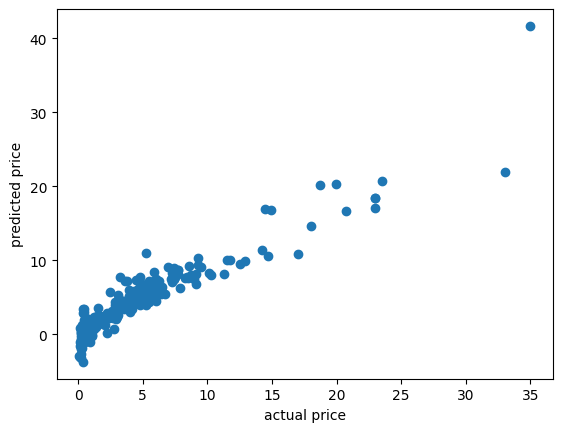

In [17]:
plt.scatter(y_train, x_train_prediction)
plt.xlabel('actual price')
plt.ylabel('predicted price')
plt.show()

In [18]:
# prediction on test data
x_test_prediction = model.predict(x_test)

In [19]:
# R squared Error
error_score=metrics.r2_score(y_test, x_test_prediction)
print("r squared error score",error_score)

r squared error score 0.8401532365377781


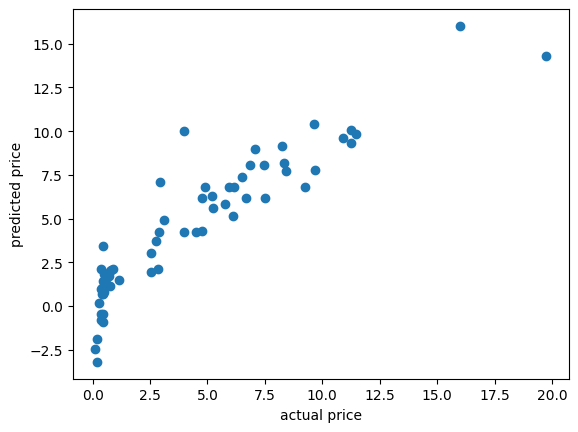

In [20]:
plt.scatter(y_test, x_test_prediction)
plt.xlabel('actual price')
plt.ylabel('predicted price')
plt.show()

# 2. Lasso Regression

In [21]:
# loading the linear regression model
model_lasso = Lasso()
model_lasso.fit(x_train, y_train)

Lasso()

## model evolution

In [22]:
x_train_prediction_lasso = model_lasso.predict(x_train)

In [23]:
error_score=metrics.r2_score(y_train, x_train_prediction_lasso)
print("r squared error score",error_score)

r squared error score 0.843587395258283


## Visualize the actual prices and Predicted prices

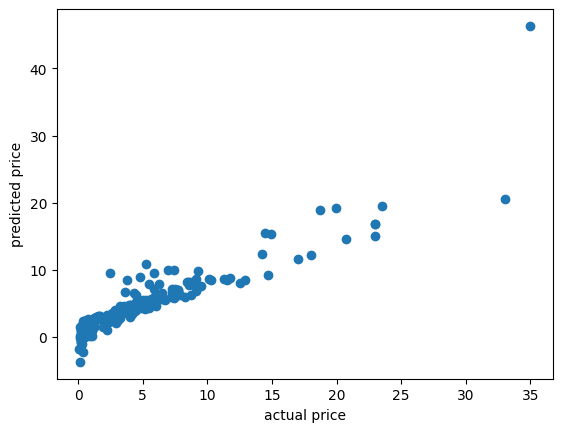

In [24]:
plt.scatter(y_train, x_train_prediction_lasso)
plt.xlabel('actual price')
plt.ylabel('predicted price')
plt.show()

In [25]:
x_test_prediction_lasso = model_lasso.predict(x_test)

In [26]:
error_score=metrics.r2_score(y_test, x_test_prediction_lasso)
print("r squared error score",error_score)

r squared error score 0.8497457570738538


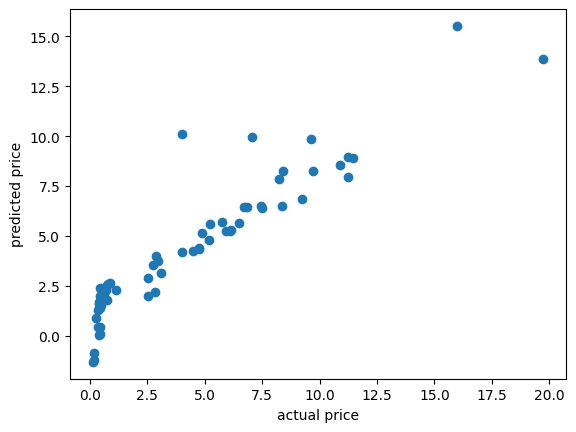

In [27]:
plt.scatter(y_test, x_test_prediction_lasso)
plt.xlabel('actual price')
plt.ylabel('predicted price')
plt.show()